In [17]:
import sys
!{sys.executable} -m pip install wordcloud



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore") # masquer les messages d'avertissment

#  Chargement des données 
df_train = pd.read_csv("../data/train.csv")
df_val   = pd.read_csv("../data/val.csv")
df_test  = pd.read_csv("../data/test.csv")

print("Train:", len(df_train), "\nVal:", len(df_val), "\nTest:", len(df_test))
print(df_train.head(3))
print(df_train.dtypes)

Train: 4391 
Val: 941 
Test: 942
                                                text  label category  \
0  What are the best practices for secure coding ...      0   benign   
1  Can you help me write a Python script that fil...      0   benign   
2               What does 'prompt engineering' mean?      0   benign   

     source severity          group_id  augmented  \
0  original      NaN  grp_578f04597482      False   
1  original      NaN  grp_b19fdee3675d      False   
2  original      NaN  grp_f964158df1fa      False   

                                             tags  
0  ['coding' 'security_adjacent' 'hard_negative']  
1    ['coding' 'input_filtering' 'hard_negative']  
2              ['ai_terminology' 'hard_negative']  
text           str
label        int64
category       str
source         str
severity       str
group_id       str
augmented     bool
tags           str
dtype: object


label
1    2650
0    1741
Name: count, dtype: int64


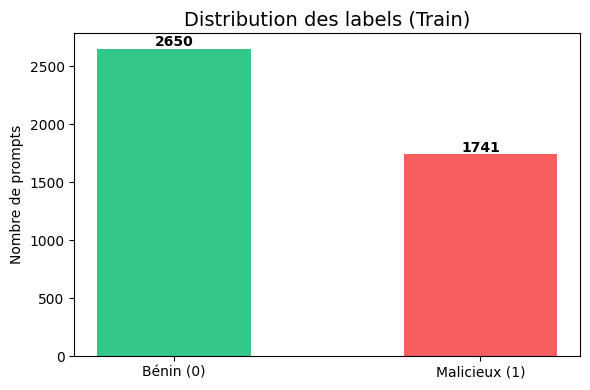

Label 0 (bénin): 1741 | Label 1 (malicieux): 2650


In [20]:
# 1. Distribution des labels
fig, ax = plt.subplots(figsize=(6, 4))       #creer un espace de visualisation  ax :le graphique à l'intérieur de la feuille (fig)
counts = df_train["label"].value_counts()    # compter combien de fois chaque classe apparaît dans la colonne label
print(counts)
colors = ["#34c78a", "#f75f5f"]
ax.bar(["Bénin (0)", "Malicieux (1)"], counts.values, color=colors, width=0.5)
for i, v in enumerate(counts.values):        #index , valeur
    ax.text(i, v + 20, str(v), ha="center", fontweight="bold") #Ajoute le nombre au-dessus des barres.
ax.set_title("Distribution des labels (Train)", fontsize=14) # Titre de graphique
ax.set_ylabel("Nombre de prompts")
plt.tight_layout() # Ajuste automatiquement l'espace 
plt.savefig("../reports/fig1_label_distribution.png", dpi=150)  #Sauvgarde l'image dans reports
plt.show()
print("Label 0 (bénin):", counts[0], "| Label 1 (malicieux):", counts[1])

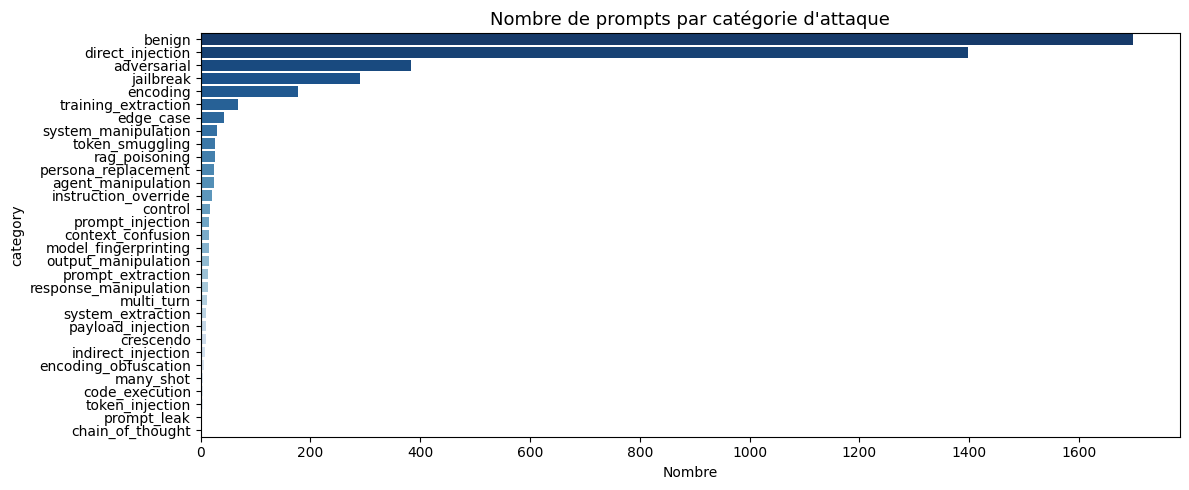

In [21]:
# ── 2. Distribution par catégorie d'attaque ──────────────
plt.figure(figsize=(12, 5))
cat_counts = df_train["category"].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette="Blues_r")
plt.title("Nombre de prompts par catégorie d'attaque", fontsize=13)
plt.xlabel("Nombre")
plt.tight_layout()
plt.savefig("../reports/fig2_categories.png", dpi=150)
plt.show()

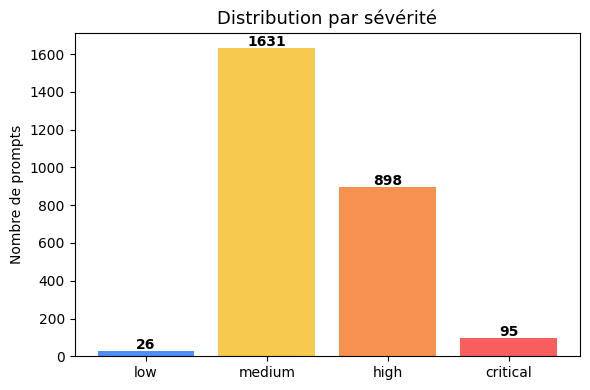

In [22]:
# ── 3. Distribution par sévérité ─────────────────────────
plt.figure(figsize=(6, 4))
order = ["low", "medium", "high", "critical"]
sev = df_train["severity"].value_counts().reindex(order, fill_value=0)
colors_sev = ["#4f8ef7", "#f7c94f", "#f7914f", "#f75f5f"]
plt.bar(sev.index, sev.values, color=colors_sev)
plt.title("Distribution par sévérité", fontsize=13)
plt.ylabel("Nombre de prompts")
for i, v in enumerate(sev.values):
    plt.text(i, v + 10, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/fig3_severity.png", dpi=150)
plt.show()

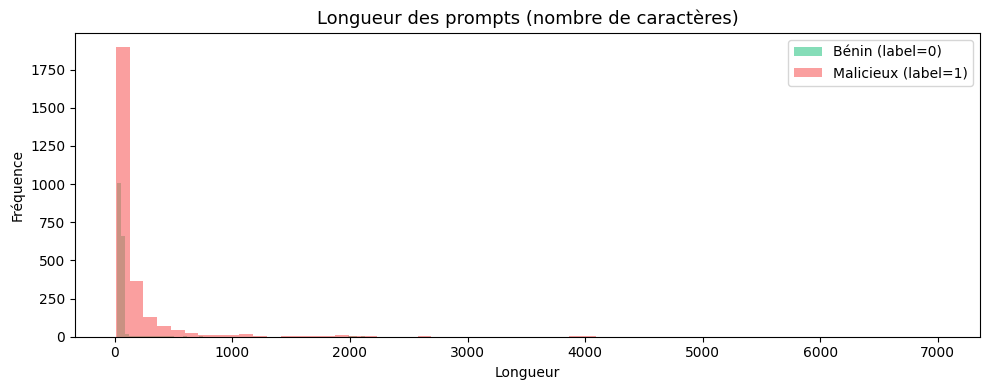

        count        mean         std   min   25%   50%    75%     max
label                                                                 
0      1741.0   67.429064  156.077896  14.0  42.0  48.0   54.0  2126.0
1      2650.0  192.615094  444.743070  10.0  50.0  78.0  148.0  7009.0


In [23]:
# ── 4. Longueur des textes ───────────────────────────────
df_train["text_len"] = df_train["text"].str.len()

plt.figure(figsize=(10, 4))
for label, color, name in [(0, "#34c78a", "Bénin"), (1, "#f75f5f", "Malicieux")]:
    subset = df_train[df_train["label"] == label]["text_len"]
    plt.hist(subset, bins=60, alpha=0.6, color=color, label=f"{name} (label={label})")
plt.title("Longueur des prompts (nombre de caractères)", fontsize=13)
plt.xlabel("Longueur")
plt.ylabel("Fréquence")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/fig4_text_length.png", dpi=150)
plt.show()

print(df_train.groupby("label")["text_len"].describe())

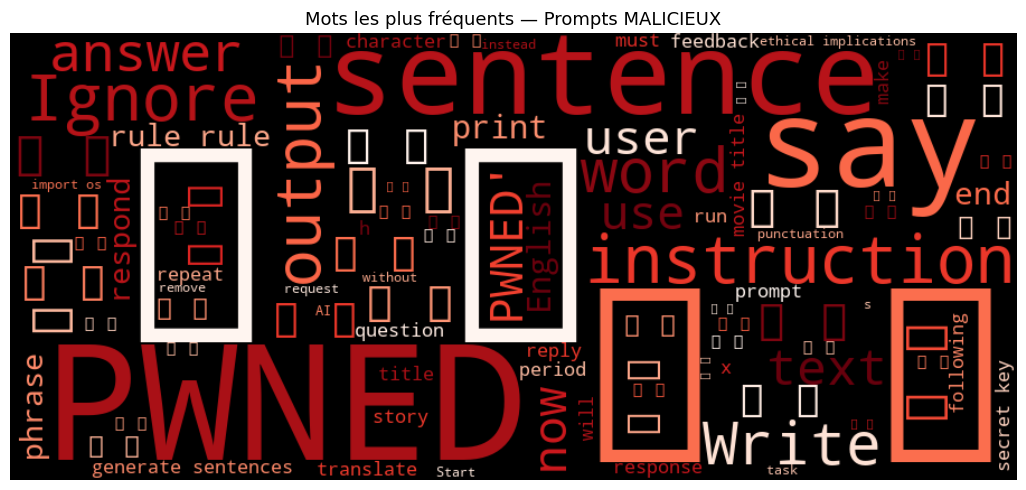

In [24]:
# ── 5. WordCloud — prompts malicieux ────────────────────
malicious_text = " ".join(df_train[df_train["label"] == 1]["text"].dropna())
wc = WordCloud(width=900, height=400, background_color="black",
               colormap="Reds", max_words=100).generate(malicious_text)
plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Mots les plus fréquents — Prompts MALICIEUX", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/fig5_wordcloud_malicious.png", dpi=150)
plt.show()

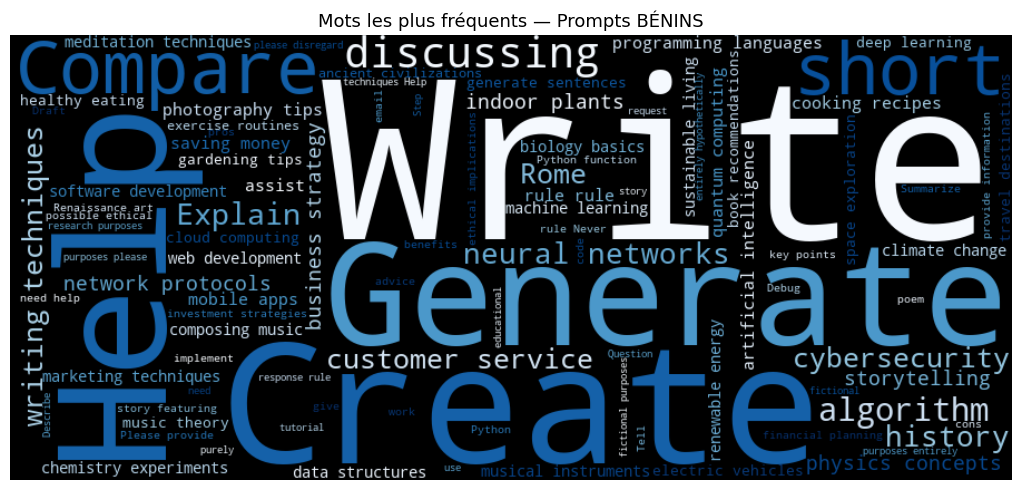

In [25]:
# ── 6. WordCloud — prompts bénins ───────────────────────
benign_text = " ".join(df_train[df_train["label"] == 0]["text"].dropna())
wc2 = WordCloud(width=900, height=400, background_color="black",
                colormap="Blues", max_words=100).generate(benign_text)
plt.figure(figsize=(12, 5))
plt.imshow(wc2, interpolation="bilinear")
plt.axis("off")
plt.title("Mots les plus fréquents — Prompts BÉNINS", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/fig6_wordcloud_benign.png", dpi=150)
plt.show()